# Customer Churn - Exploratory Data Analysis
This notebook covers initial data loading, understanding the structure,
checking data quality, and getting a feel for the dataset before any cleaning or modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# consistent plot styling throughout the project
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

# load dataset
df = pd.read_csv('../data/raw/Telco_customer_churn.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 3 rows:")
df.head(3)

Dataset Shape: (7043, 33)

First 3 rows:


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved


## 1. Dataset Overview
Checking column names, data types, and basic info to understand what we're working with.

In [2]:
# checking data types and non-null counts
print("Dataset Info:")
print("-" * 40)
df.info()

Dataset Info:
----------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-

In [3]:
# checking unique values in each column to spot any hidden issues
print("Unique values per column:")
print("-" * 40)
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Unique values per column:
----------------------------------------
CustomerID: 7043 unique values
Count: 1 unique values
Country: 1 unique values
State: 1 unique values
City: 1129 unique values
Zip Code: 1652 unique values
Lat Long: 1652 unique values
Latitude: 1652 unique values
Longitude: 1651 unique values
Gender: 2 unique values
Senior Citizen: 2 unique values
Partner: 2 unique values
Dependents: 2 unique values
Tenure Months: 73 unique values
Phone Service: 2 unique values
Multiple Lines: 3 unique values
Internet Service: 3 unique values
Online Security: 3 unique values
Online Backup: 3 unique values
Device Protection: 3 unique values
Tech Support: 3 unique values
Streaming TV: 3 unique values
Streaming Movies: 3 unique values
Contract: 3 unique values
Paperless Billing: 2 unique values
Payment Method: 4 unique values
Monthly Charges: 1585 unique values
Total Charges: 6531 unique values
Churn Label: 2 unique values
Churn Value: 2 unique values
Churn Score: 85 unique values
CLTV: 3

In [4]:
# checking our target variable distribution
print("Churn Distribution:")
print("-" * 40)
print(df['Churn Label'].value_counts())
print("\nChurn Percentage:")
print(df['Churn Label'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Churn Distribution:
----------------------------------------
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn Label
No     73.46%
Yes    26.54%
Name: proportion, dtype: str


## 2. Target Variable Distribution
Visualizing churn balance to understand class imbalance before modeling.

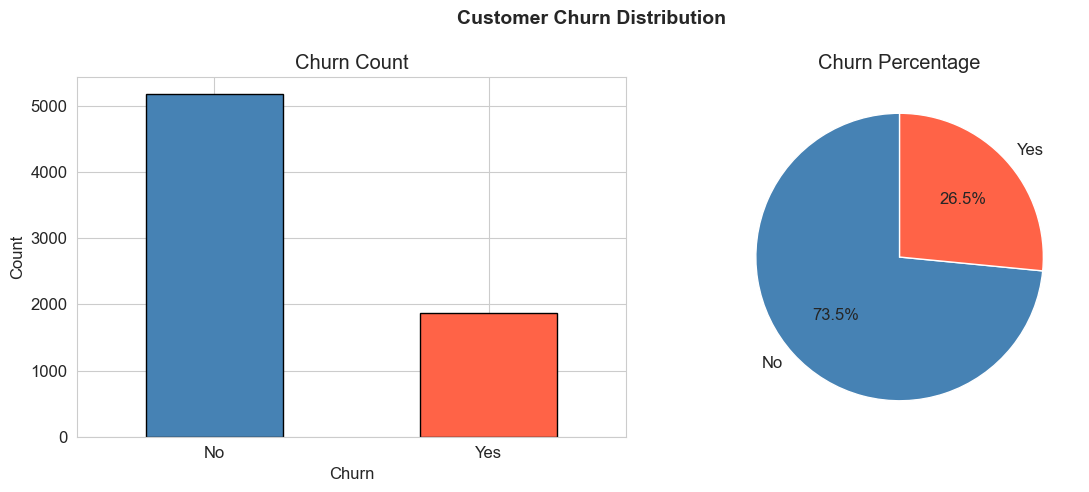

In [5]:
# visualizing churn distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# bar chart
df['Churn Label'].value_counts().plot(kind='bar', ax=axes[0], 
                                       color=['steelblue', 'tomato'], 
                                       edgecolor='black')
axes[0].set_title('Churn Count')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

# pie chart
df['Churn Label'].value_counts().plot(kind='pie', ax=axes[1],
                                       autopct='%1.1f%%',
                                       colors=['steelblue', 'tomato'],
                                       startangle=90)
axes[1].set_title('Churn Percentage')
axes[1].set_ylabel('')

plt.suptitle('Customer Churn Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Numerical Features Analysis
Understanding the distribution of key numerical columns - tenure, monthly charges, total charges and CLTV.

In [6]:
# converting Total Charges to numeric - some rows may have spaces instead of values
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

# check how many got converted to NaN
print("NaN in Total Charges after conversion:", df['Total Charges'].isna().sum())

NaN in Total Charges after conversion: 11


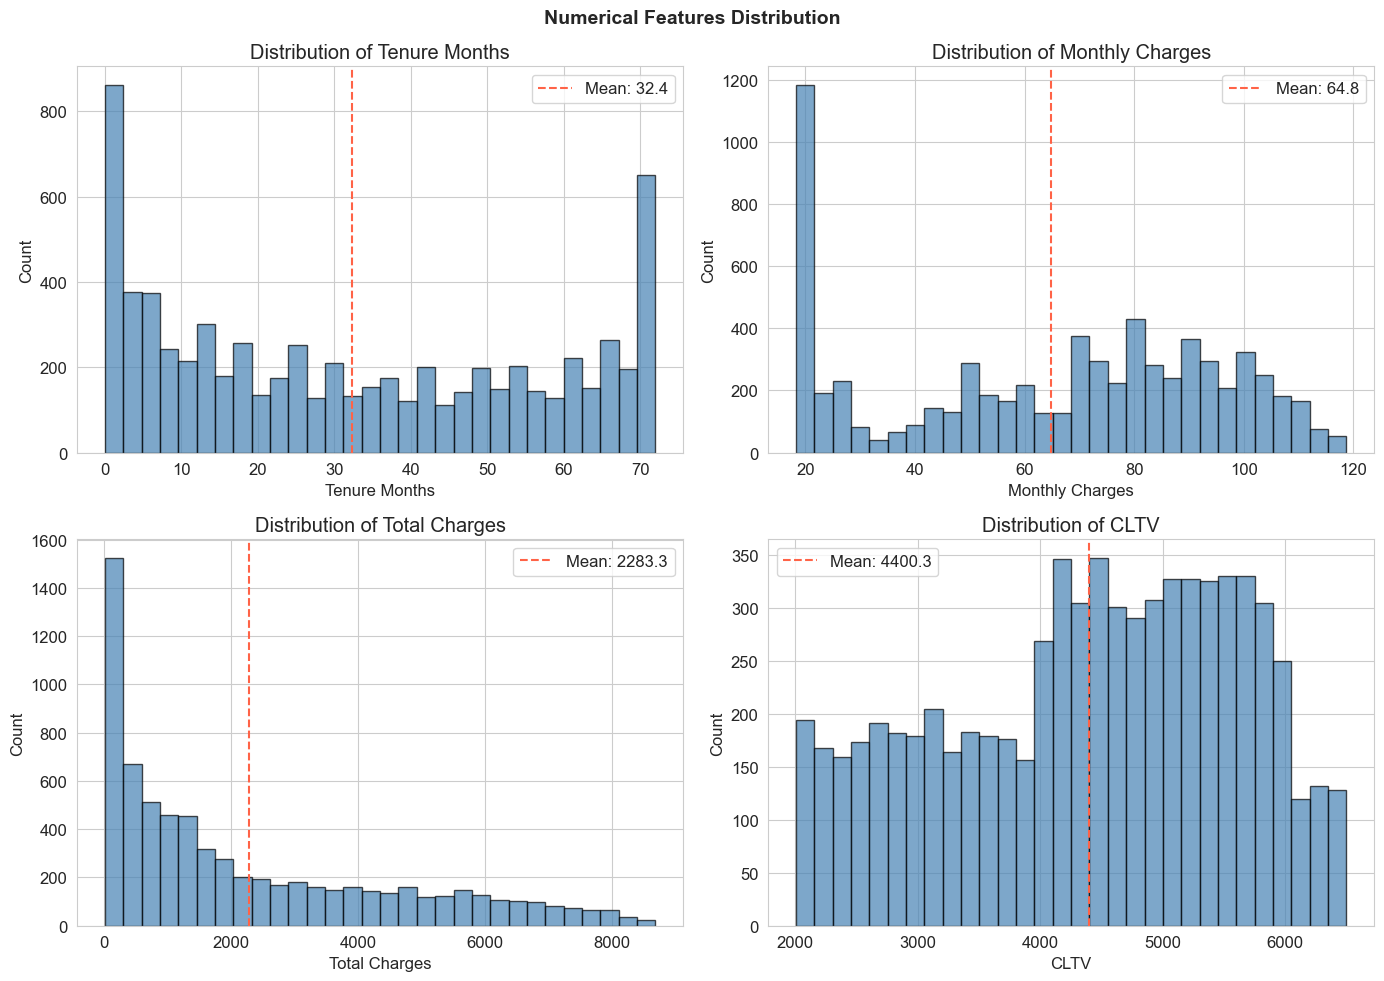

In [7]:
# selecting only the useful numerical columns
num_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].axvline(df[col].mean(), color='tomato', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.suptitle('Numerical Features Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/numerical_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Churn vs Numerical Features
Comparing how numerical features differ between churned and non-churned customers.

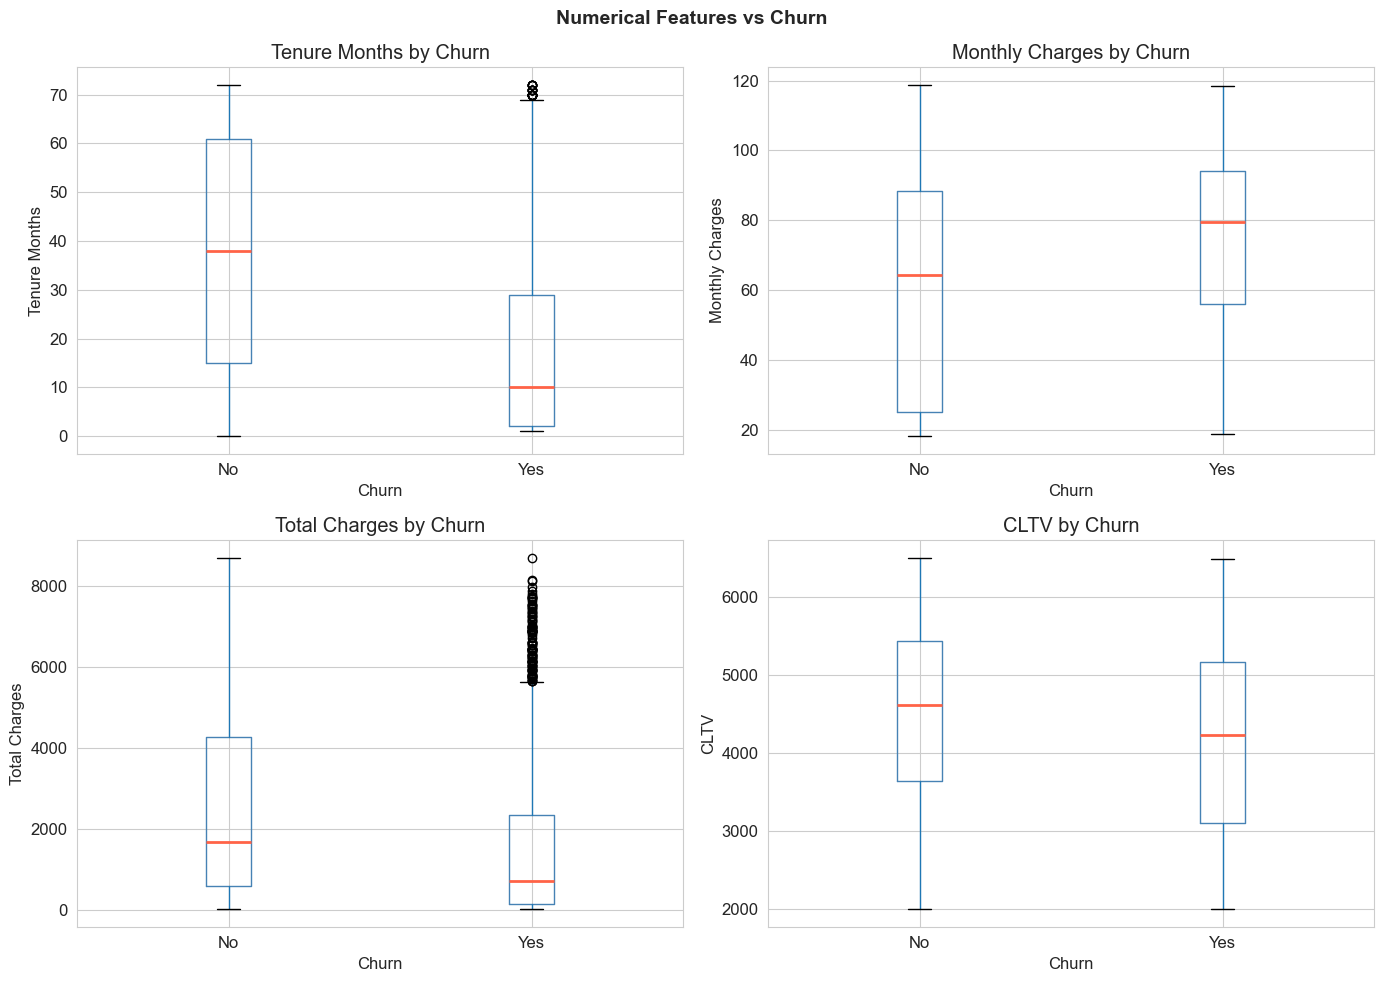

In [8]:
# boxplots to compare numerical features between churned and non-churned customers
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df.boxplot(column=col, by='Churn Label', ax=axes[i], 
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='tomato', linewidth=2))
    axes[i].set_title(f'{col} by Churn')
    axes[i].set_xlabel('Churn')
    axes[i].set_ylabel(col)

plt.suptitle('Numerical Features vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/numerical_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Categorical Features vs Churn
Analyzing how contract type, payment method, internet service and other categorical features relate to churn.

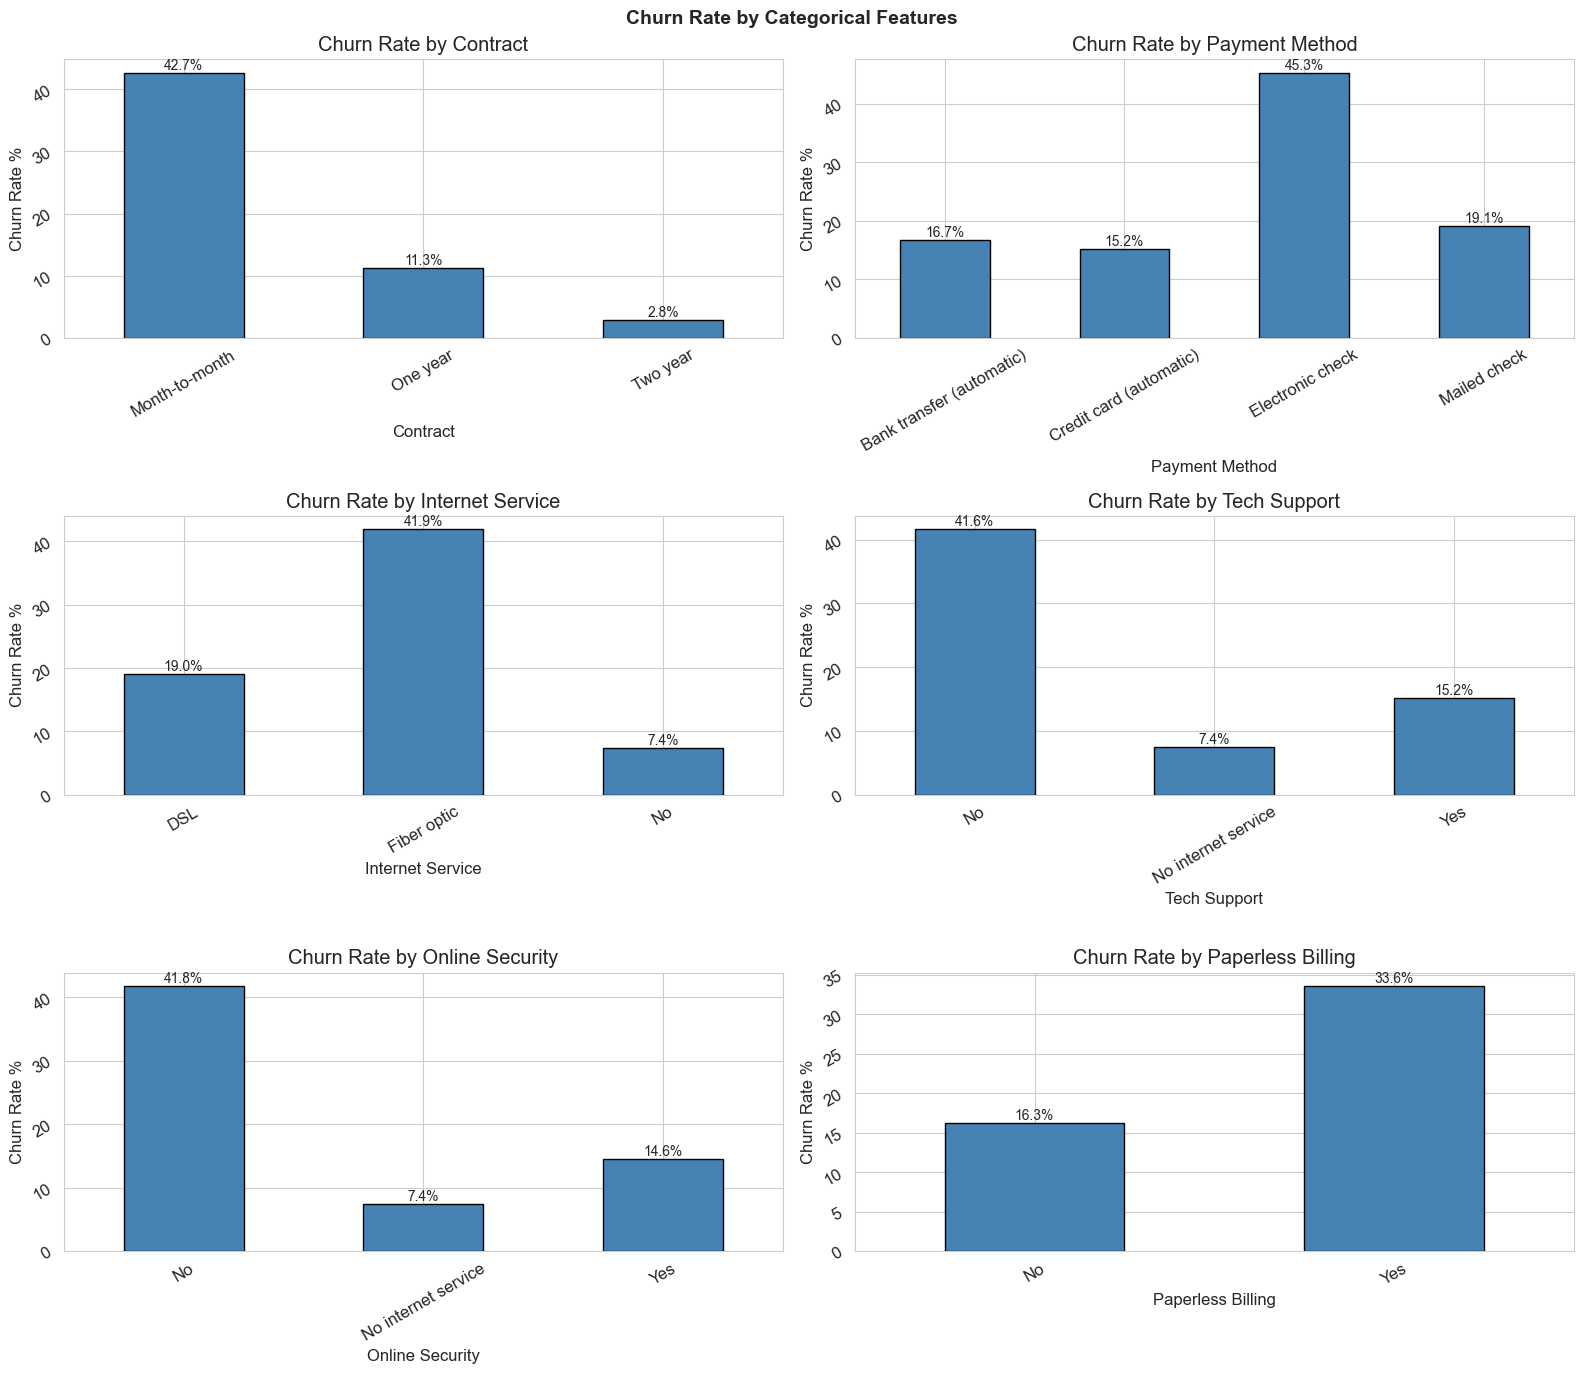

In [9]:
# categorical columns we care about for churn analysis
cat_cols = ['Contract', 'Payment Method', 'Internet Service', 
            'Tech Support', 'Online Security', 'Paperless Billing']

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn Value'].mean().mul(100).round(1)
    churn_rate.plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Churn Rate %')
    axes[i].tick_params(rotation=30)
    
    # adding value labels on bars
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.1f}%', 
                        (p.get_x() + p.get_width() / 2, p.get_height()),
                        ha='center', va='bottom', fontsize=10)

plt.suptitle('Churn Rate by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/categorical_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Churn Reasons Analysis
Understanding why customers actually left - this will power our retention recommendation engine.

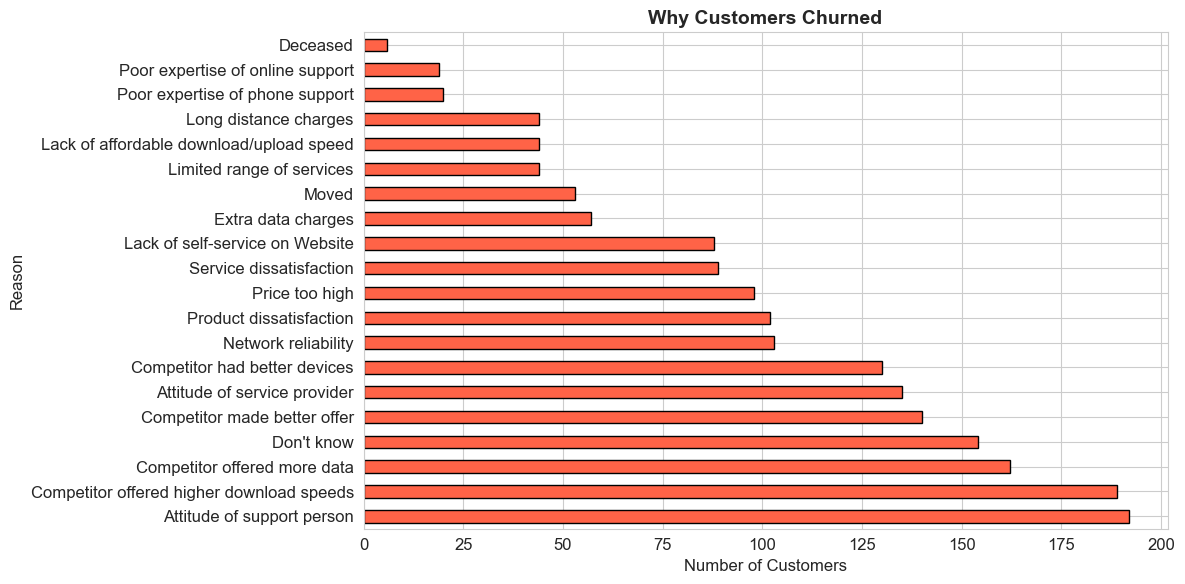


Top 5 Churn Reasons:
Churn Reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Don't know                                   154
Competitor made better offer                 140
Name: count, dtype: int64


In [10]:
# analyzing churn reasons - only for customers who actually churned
churn_reasons = df[df['Churn Label'] == 'Yes']['Churn Reason'].value_counts()

plt.figure(figsize=(12, 6))
churn_reasons.plot(kind='barh', color='tomato', edgecolor='black')
plt.title('Why Customers Churned', fontsize=14, fontweight='bold')
plt.xlabel('Number of Customers')
plt.ylabel('Reason')
plt.tight_layout()
plt.savefig('../reports/churn_reasons.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 Churn Reasons:")
print(churn_reasons.head())

## 7. Correlation Analysis
Checking how numerical features relate to each other and to churn.

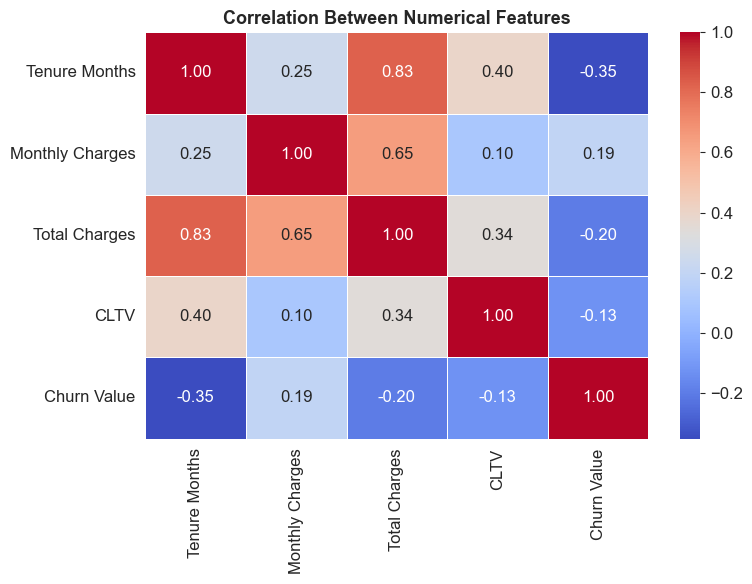

In [11]:
# correlation heatmap for numerical columns
corr_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'Churn Value']

plt.figure(figsize=(8, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', 
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Between Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Senior Citizen & Demographics vs Churn
Checking if age and personal demographics play a role in churn behavior.

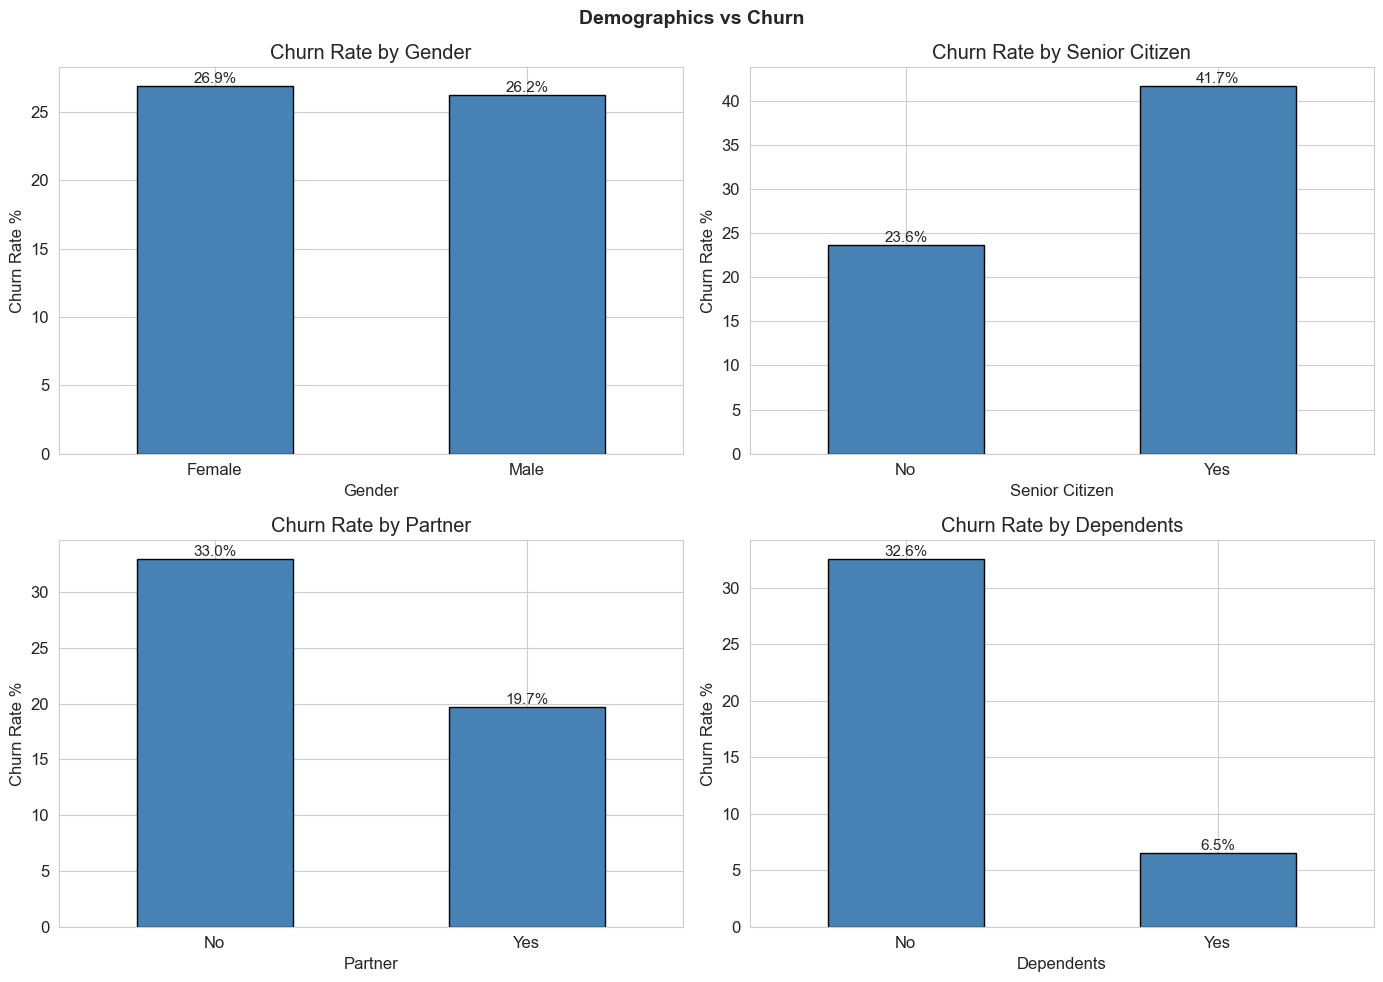

In [ ]:
# demographic analysis vs churn
demo_cols = ['Gender', 'Senior Citizen', 'Partner', 'Dependents']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(demo_cols):
    churn_rate = df.groupby(col)['Churn Value'].mean().mul(100).round(1)
    churn_rate.plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Churn Rate %')
    axes[i].tick_params(rotation=0)
    
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.1f}%',
                        (p.get_x() + p.get_width() / 2, p.get_height()),
                        ha='center', va='bottom', fontsize=11)

plt.suptitle('Demographics vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/demographics_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

## EDA Summary
- Tenure and contract type are the strongest churn indicators
- Month-to-month customers churn 15x more than two-year contract customers
- Electronic check payment method has highest churn rate at 45.3%
- Senior citizens, singles and customers without dependents are high risk
- Top churn reason is poor support experience followed by competitor offers
- Monthly Charges and CLTV will be key for revenue-at-risk calculations